### 1. Imports

In [32]:
import numpy as np
import pandas as pd 
import seaborn as sns
import json
import unidecode
from matplotlib import pyplot as plt
import ast
from flaml import AutoML
from sklearn.cluster import KMeans
import ast
from sklearn.model_selection import train_test_split
# Usar autogluon 
from autogluon.tabular import TabularPredictor
import re

In [2]:
import warnings 
warnings.filterwarnings("ignore")

### 2. Cargar datos y visualización

In [3]:
train_df = pd.read_csv('../data/train_split.csv')
test_df = pd.read_csv('../data/test_split.csv') 

# Train & test dataframes  shape
print(train_df.shape, test_df.shape)

(110000, 70) (39867, 70)


In [4]:
# Primera overview de los features/target del dataframe de train
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110000 entries, 0 to 109999
Data columns (total 70 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  110000 non-null  int64  
 1   ciudad                              110000 non-null  object 
 2   estado                              110000 non-null  object 
 3   estado_propiedad                    110000 non-null  object 
 4   dormitorios                         102884 non-null  float64
 5   banos                               106172 non-null  float64
 6   precio                              109968 non-null  float64
 7   anio_construccion                   9003 non-null    float64
 8   codigo_postal                       110000 non-null  int64  
 9   longitud                            109666 non-null  float64
 10  latitud                             109666 non-null  float64
 11  geocodificacion_deficiente

In [5]:
# Determino intersección en columnas entre train y test
common_cols = train_df.columns.intersection(test_df.columns)
len(common_cols)

70

In [6]:
# Elimino las columnas id de ambos datasets
train_df.drop(columns=['id'], inplace=True)

test_ids_list = test_df['id'].values # Extraemos para luego usarlo en el submission 
test_df.drop(columns=['id'], inplace=True)

In [13]:
train_df.columns

Index(['ciudad', 'estado', 'estado_propiedad', 'dormitorios', 'banos',
       'precio', 'anio_construccion', 'codigo_postal', 'longitud', 'latitud',
       'geocodificacion_deficiente', 'area_habitable', 'tipo_vivienda',
       'tamano_lote', 'valor_area_lote', 'unidades_area_lote',
       'valor_area_habitable', 'unidades_area_habitable_corto',
       'direccion_no_divulgada', 'fecha_venta_texto', 'pais',
       'tasa_impuesto_propiedad', 'conteo_fotos', 'es_constructor_premier',
       'conteo_vistas_recorrido', 'tiene_video_publico',
       'unidades_area_habitable', 'url_tour_virtual_tercero_aprobado',
       'ocupado_no_propietario', 'descripcion', 'escuelas', 'tasas_hipoteca',
       'oferta_inmediata_habilitada', 'ciudades_cercanas',
       'vecindarios_cercanos', 'codigos_postales_cercanos', 'dias_en_portal',
       'nombre_corredor', 'dimension_tipo_propiedad', 'dimension_tipo_hdp',
       'zona_horaria', 'elegibilidad_recorrido', 'auto_recorrido',
       'datos_residenciales_

In [14]:
# Selecciono features numéricos y categóricos
numerical_FEATURES = train_df.select_dtypes(['int64','float64']).columns
categorical_FEATURES = train_df.select_dtypes(['object']).columns

In [15]:
# Visualización estadísticos descriptivos de las variables numéricas
train_df[numerical_FEATURES].describe().T.sort_values(by='std').style.background_gradient(cmap='GnBu')

,count,mean,std,min,25%,50%,75%,max
tasa_impuesto_propiedad,109963.000000,1.634174,0.310859,0.000000,1.460000,1.730000,1.840000,2.160000
dormitorios,102884.000000,2.939116,1.262672,0.000000,2.000000,3.000000,4.000000,91.000000
latitud,109666.000000,27.720004,1.485288,24.548346,26.424290,27.704355,28.708632,46.833220
longitud,109666.000000,-81.700261,1.564072,-111.477200,-82.336218,-81.614458,-80.334870,-70.615395
banos,106172.000000,2.417070,6.875272,0.000000,2.000000,2.000000,3.000000,2204.000000
conteo_vistas_recorrido,109963.000000,0.190782,15.505444,0.000000,0.000000,0.000000,0.000000,3384.000000
conteo_fotos,110000.000000,34.996864,20.516846,0.000000,21.000000,33.000000,47.000000,209.000000
dias_en_portal,109968.000000,128.431416,158.134698,-33.000000,32.000000,83.000000,168.000000,4908.000000
dias_en_portal_detalle,109886.000000,128.486531,158.168976,-33.000000,32.000000,83.000000,168.000000,4908.000000
anio_construccion,9003.000000,2008.608020,675.901256,0.000000,1988.000000,2018.000000,2025.000000,65535.000000


In [16]:
# Features a no considerar debido a la gran cantidad de nules
FEATURES2DROP = [
    "datos_residenciales_alcantarillado", 
    "datos_residenciales_fuente_agua", 
    "numero_unidad",
    "pies_cuadrados",
    "fecha_disponibilidad",
    "oferta_especial",
    "anio_construccion",
    ## Añado variables que no aportan importancia
    'es_destacado', 
    'avaluo_vivienda',
    'conteo_visitas_recorrido', 
    'oferta_inmediata_habilitada']
    
# Extraigo el precio de las variables FEATURES ya que es el target
TARGET = "precio"
FEATURES2DROP +=[TARGET] 
numerical_FEATURES = [f for f in numerical_FEATURES if f not in FEATURES2DROP]

#### 2.1. Visualización numerical features

,count,mean,std,min,25%,50%,75%,max
precio,109968.0,745150.713689,2.191973e+06,0.0,249900.0,398997.0,650000.0,285000000.0


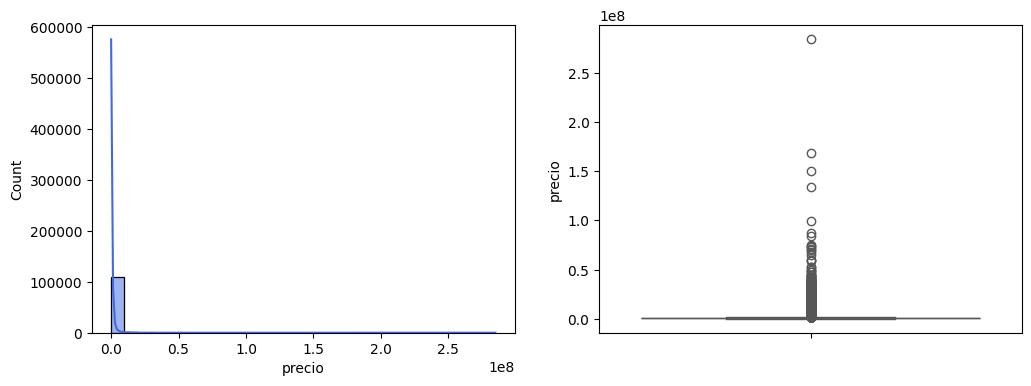

In [17]:
# Visualización variable target
fig, axes = plt.subplots(1, 2, figsize = (12,4))

sns.histplot(train_df[TARGET], kde=True, bins = 30, color="royalblue",label="train", ax= axes[0])
sns.boxplot(train_df[TARGET],color="royalblue", label="train", ax= axes[1])
pd.DataFrame(train_df[TARGET].describe()).T

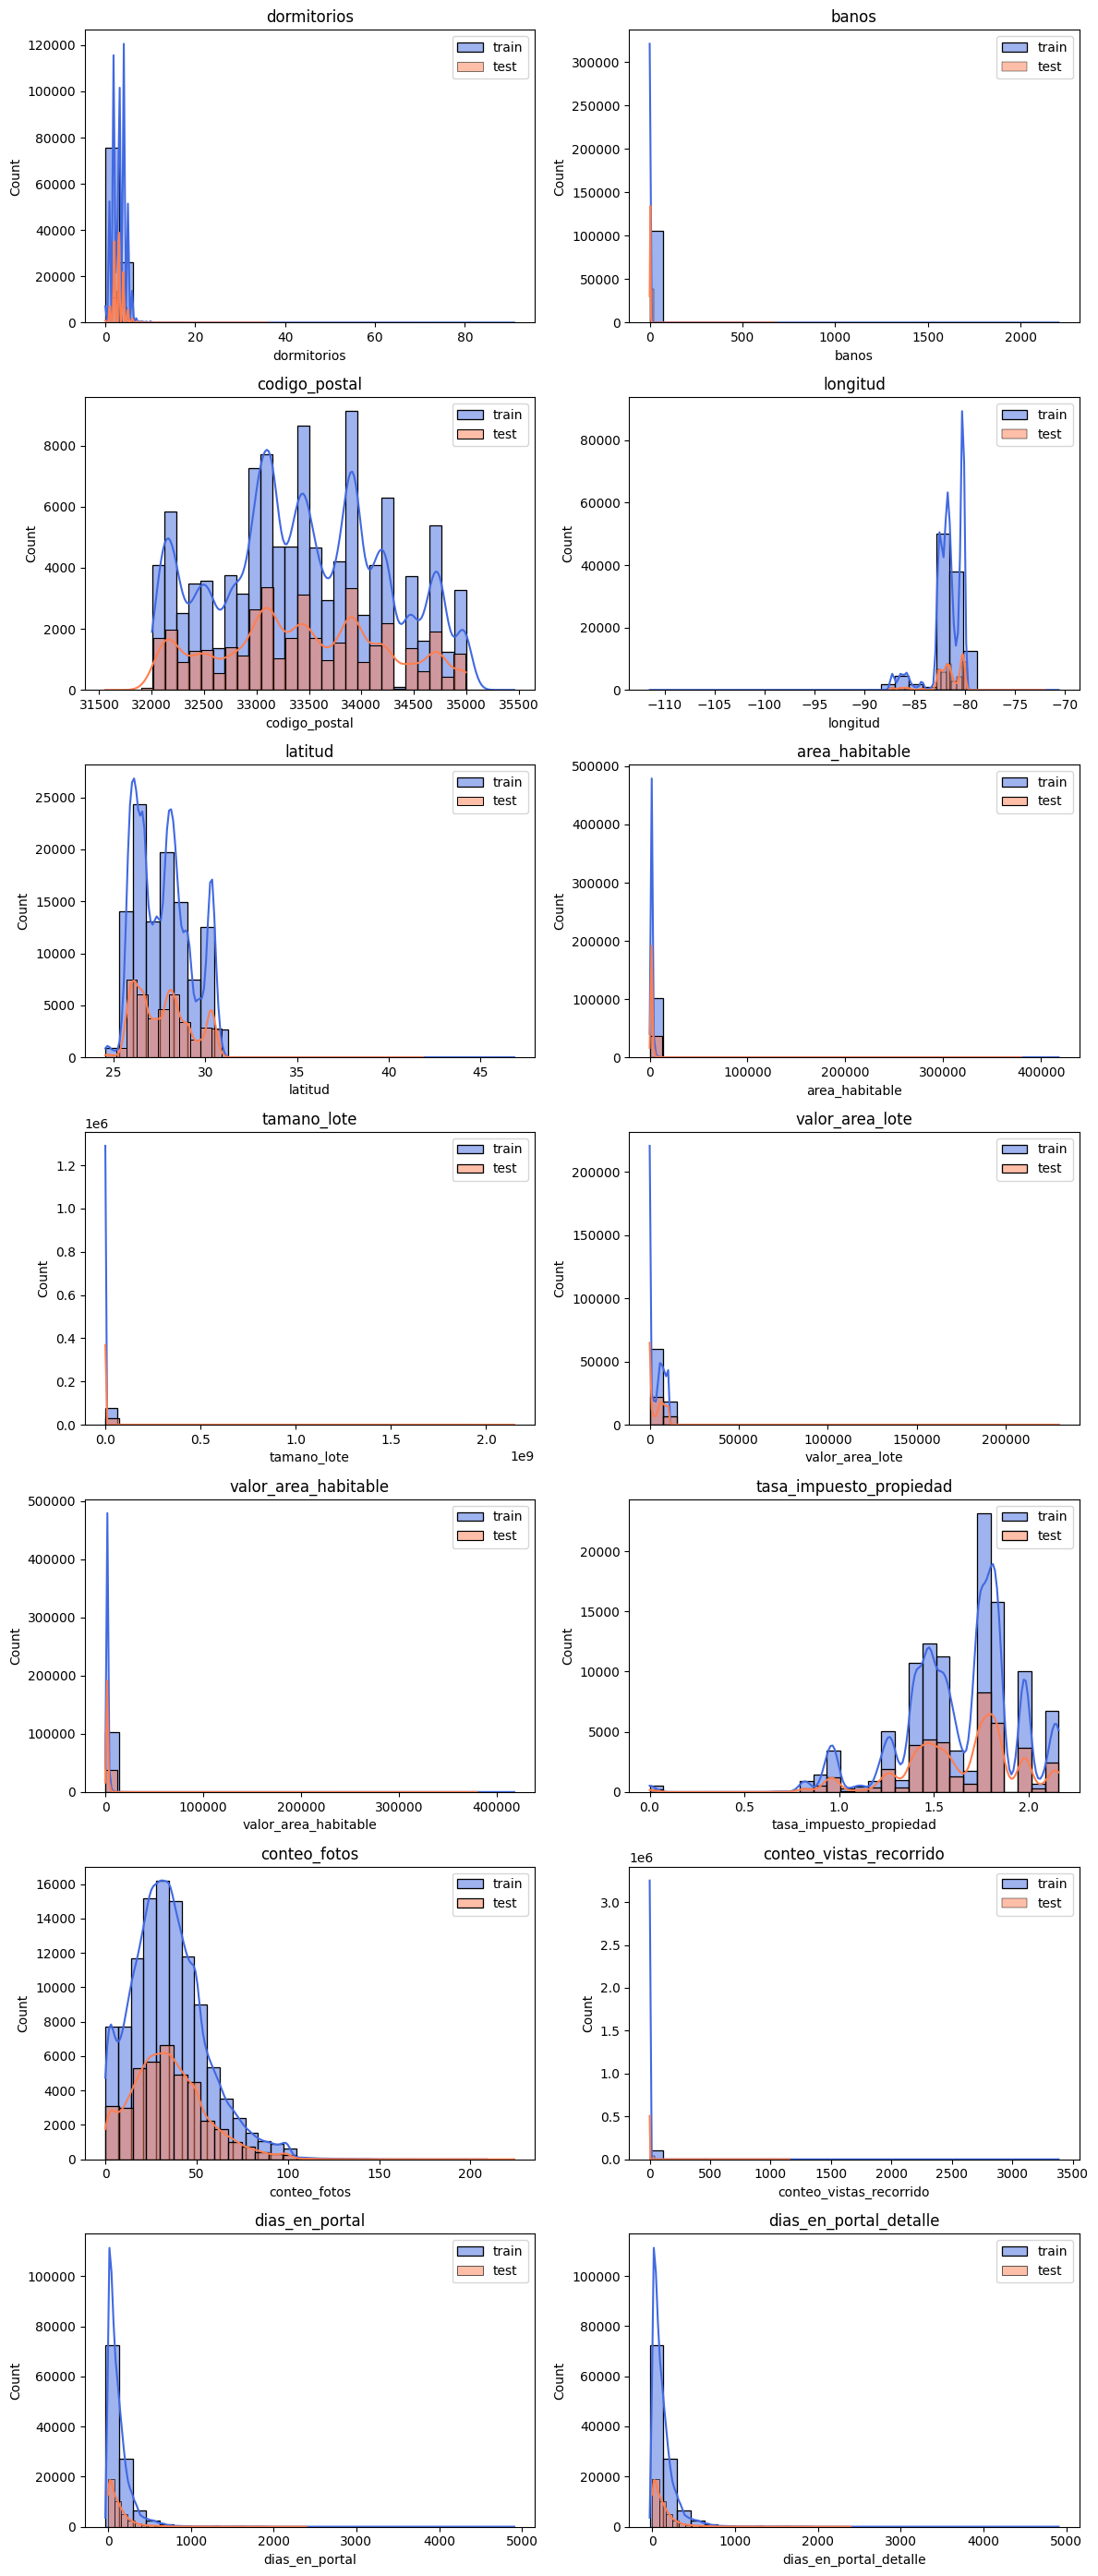

In [18]:
# Visualización de los features numéricos - Comparativa train y test
numerical_FEATURES = train_df[numerical_FEATURES].describe().T.index.tolist()

n_cols = 2
n_rows = (len(numerical_FEATURES) + n_cols - 1) // n_cols  # redondeo hacia arriba
fig, axes = plt.subplots(n_rows, n_cols, figsize = (12,n_rows*4))
axes = axes.flatten()  # facilita indexar los subplots

for i, feature in enumerate(numerical_FEATURES):
    sns.histplot(train_df[feature], kde=True, bins = 30, ax=axes[i], color="royalblue",label="train")
    sns.histplot(test_df[feature], kde=True, bins=30, ax = axes[i], color="coral",label="test")
    axes[i].set_title(feature)
    axes[i].legend()

# Apagar ejes vacíos (si los hay)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

Como puede observarse en los gráficos hay muchos features skewed, por ejemplo: 

Right skewed: 
- Dormitorios
- banos
- precio
- area habitable
- tamano lote
- valor_area_lote
- valor_area_habitable
- conteo_vistas_recorrido
- dias en portal
- dias_en_portal_detalle

Tendrá que decidirse que hacer con los valores atípicos para los features right skewed y como inputar los NaN. 
 
Nota: El codigo postal es una variable numérica pero no debería usarse como variable continua porque no tiene relacion ordinal, las distancias numericas no representan distancias geograficas reales. Lo mejor es hacer one hot encoding o sustituirla por otra variable

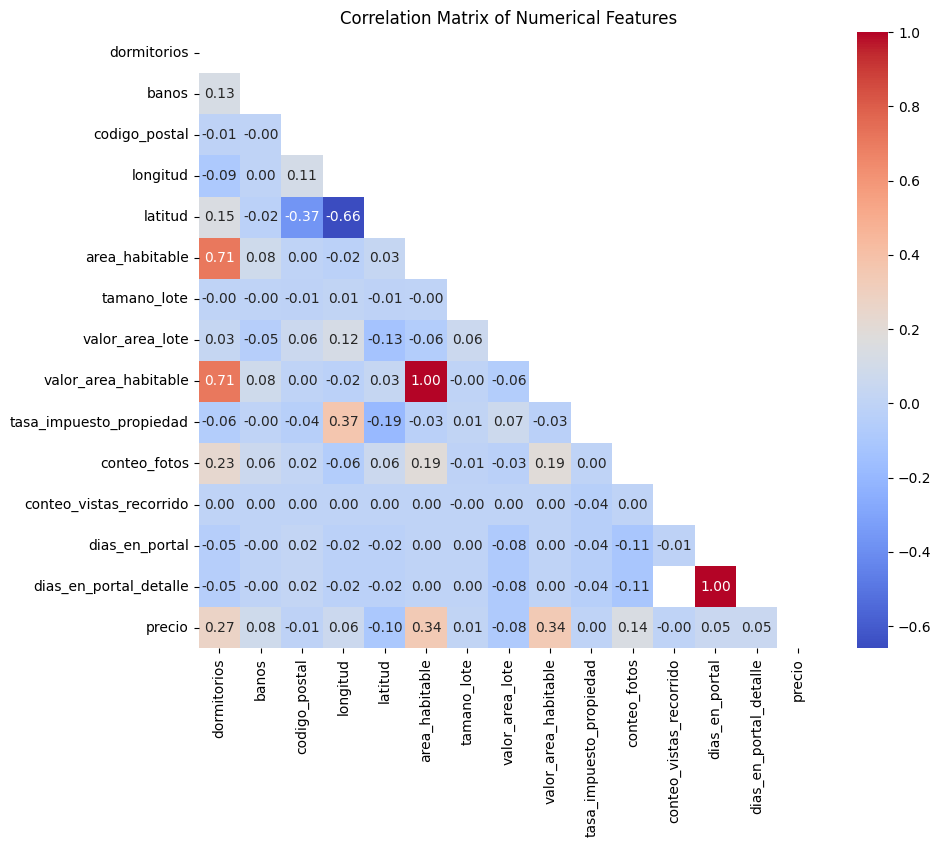

In [20]:
# Correlación entre variables numéricas
mask = np.triu(np.ones_like(train_df[numerical_FEATURES + ['precio']].corr().round(2), dtype=bool))
correlation_matrix = train_df[numerical_FEATURES + ['precio']].corr().round(2)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm",mask=mask, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

Como puede verse en la matriz de correlación, hay variables altamente correladas: 
- Area habitable y valor area habitable con dormitorios
- Dias en portal con dias en portal detalle es prácticamente lo mismo

### 2.2. Añadir embeddings ADA

Se han calculado los embeddings de la columna "descripción" a través del modelo **text-embedding-ada-002** en su configuración 256 dimensiones

In [21]:
# Cargamos embeddings precalculados 
df_train_embeddings = pd.read_csv('../data/hc_proyecto_train_data_embeddings.csv')
df_test_embeddings = pd.read_csv('../data/hc_proyecto_test_data_embeddings.csv')


Al almacenar los embeddings estos se han guardado como string. Se define la siguiente función para transformarlos y generar un dataframe

In [22]:
def parse_numpy_str(s):
    s = s.strip("[]")
    s = s.replace(',', ' ')
    arr = np.fromstring(s, sep=' ').tolist()
    return arr

df_train_embeddings['descripcion_embeddings'] = df_train_embeddings['descripcion_embeddings'].apply(parse_numpy_str)
df_test_embeddings['descripcion_embeddings'] = df_test_embeddings['descripcion_embeddings'].apply(parse_numpy_str)


La introducción "raw" del embeddings para el entrenamiento de modelos a través de autogluon o otros AUTOML no es posible. Se genera una columna para cada una de las dimensiones

In [23]:
embedding_dim = len(df_train_embeddings.iloc[0]["descripcion_embeddings"])
# Convertir la columna de embeddings en una matriz 2D
emb_matrix = np.vstack(df_train_embeddings["descripcion_embeddings"].values)
# Crear un nuevo dataframe de columnas emb_0, emb_1, ...
emb_df = pd.DataFrame(
    emb_matrix,
    columns=[f"emb_{i}" for i in range(embedding_dim)]
)

embedding_dim_2 = len(df_test_embeddings.iloc[0]["descripcion_embeddings"])
# Convertir la columna de embeddings en una matriz 2D
emb_matrix_2 = np.vstack(df_test_embeddings["descripcion_embeddings"].values)
# Crear un nuevo dataframe de columnas emb_0, emb_1, ...
emb_df_2 = pd.DataFrame(
    emb_matrix_2,
    columns=[f"emb_{i}" for i in range(embedding_dim_2)]
)


train_df = pd.concat([train_df, emb_df],axis=1)
test_df = pd.concat([test_df, emb_df_2],axis=1)


In [24]:
train_df.info()
train_df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110000 entries, 0 to 109999
Columns: 325 entries, ciudad to emb_255
dtypes: bool(1), float64(276), int64(2), object(46)
memory usage: 272.0+ MB


,ciudad,estado,estado_propiedad,dormitorios,banos,precio,anio_construccion,codigo_postal,longitud,latitud,...,emb_246,emb_247,emb_248,emb_249,emb_250,emb_251,emb_252,emb_253,emb_254,emb_255
0,Lakeland,FL,FOR_SALE,3.0,2.0,119900.0,NaN,33810,-81.97661,28.146996,...,0.055814,0.083686,-0.002043,0.069716,0.094002,-0.034311,-0.043107,0.045225,0.055779,-0.000019
1,Pompano Beach,FL,FOR_SALE,3.0,2.0,290000.0,NaN,33067,-80.24621,26.287040,...,0.054837,0.142771,-0.021663,0.012974,0.083022,-0.025964,-0.021053,-0.034879,0.058153,0.063659
2,Jacksonville,FL,FOR_SALE,3.0,3.0,599000.0,NaN,32205,-81.71293,30.296097,...,0.022639,0.138726,-0.025745,0.000391,0.048933,-0.099128,0.054381,0.026659,-0.045843,0.021626


In [25]:
# Train & test dataframes  shape
print(train_df.shape, test_df.shape)

(110000, 325) (39867, 325)


Compruebo que las columnas entre train y test sean las mismas

In [26]:
# Determino intersección en columnas entre train y test
common_cols = train_df.columns.intersection(test_df.columns)
len(common_cols)

325

###  3. Imputación de variables numericas

In [27]:
# Quitar los registros del train que tengan NaN
train_df = train_df[~train_df['precio'].isna()]

In [ ]:
### Imputar nans en area_habitable usando medianas condicionadas
# Mediana del área habitable teniendo en cuenta la cantidad de baños y habitaciones 
median_map_full = train_df.groupby(["banos", "dormitorios"])["area_habitable"].median()

# Mediana del área habitable solo teniendo en cuenta el nº de habitaciones  
median_map_rooms = train_df.groupby(["dormitorios"])["area_habitable"].median()

# Mediana del área habitable solo teniendo en cuenta el nº de baños
median_map_bath = train_df.groupby(["banos"])["area_habitable"].median()

# Mediana global del train_df
global_median = train_df["area_habitable"].median()

# Funcion para imputar el área
def impute_area(row):
    if not pd.isna(row["area_habitable"]):
        return row["area_habitable"]

    # 1. Por (baños, habitaciones)
    key_full = (row["banos"], row["dormitorios"])
    val = median_map_full.get(key_full)
    if not pd.isna(val):
        return val

    # 2. Solo por habitaciones
    val = median_map_rooms.get(row["dormitorios"])
    if not pd.isna(val):
        return val

    # 3. Solo por baños
    val = median_map_bath.get(row["banos"])
    if not pd.isna(val):
        return val

    # 4. Mediana global del train
    return global_median

# Función para rellenar nans con la mediana del feature del dataset introducido
def fill_nans_with_median(train_df, test_df, feature): 
    mediana_dorm = train_df[feature].median()
    train_df[feature] = train_df[feature].fillna(mediana_dorm)
    test_df[feature] = test_df[feature].fillna(mediana_dorm)
    return train_df, test_df

# Función para rellenar nans con la moda del feature del datset introducido
def fill_nans_with_mode(train_df, test_df, feature): 
    mediana_dorm = train_df[feature].mode()[0]
    train_df[feature] = train_df[feature].fillna(mediana_dorm)
    test_df[feature] = test_df[feature].fillna(mediana_dorm)
    return train_df, test_df


In [ ]:
# Variables numéricas

# Imputar NaNs tanto en train como en test
train_df, test_df = fill_nans_with_mode(train_df, test_df, 'dormitorios')
train_df, test_df = fill_nans_with_mode(train_df, test_df, 'banos')
train_df, test_df = fill_nans_with_mode(train_df, test_df, 'dias_en_portal')

train_df["area_habitable"] = train_df.apply(impute_area, axis=1)
test_df["area_habitable"] = test_df.apply(impute_area, axis=1)

# Hay casos donde el value_counts es 1 o hay discrepancias en algunas casuísticas. 
# Por lo que decido seleccionar la zona horaria por ciudad con más frecuencia de aparición. 
zona_horaria_dominante = (train_df.groupby("codigo_postal")["zona_horaria"].agg(lambda x: x.value_counts().idxmax()))
train_df['zona_horaria'] = train_df['codigo_postal'].map(zona_horaria_dominante)
test_df['zona_horaria'] = test_df['codigo_postal'].map(zona_horaria_dominante)


## Tasa de impuesto de propiedad
# Ajustarla por codigo_postal a la mediana del valor del codigo postal

cp_impuesto_dict = dict(train_df.groupby('codigo_postal')['tasa_impuesto_propiedad'].median())
train_df['tasa_impuesto_propiedad'] = train_df['tasa_impuesto_propiedad'].fillna(train_df['codigo_postal'].map(cp_impuesto_dict))
# Si se mantiene algun NaN sustituir por la mediana global
train_df['tasa_impuesto_propiedad'] = train_df['tasa_impuesto_propiedad'].fillna(train_df['tasa_impuesto_propiedad'].median())

test_df['tasa_impuesto_propiedad'] = test_df['tasa_impuesto_propiedad'].fillna(test_df['codigo_postal'].map(cp_impuesto_dict))
test_df['tasa_impuesto_propiedad'] = test_df['tasa_impuesto_propiedad'].fillna(train_df['tasa_impuesto_propiedad'].median())


# Para latitud y longitud considerar la mediana por zona
media_lat_por_cp = dict(train_df.groupby('codigo_postal')['latitud'].mean())
media_long_por_cp = dict(train_df.groupby('codigo_postal')['longitud'].mean())

train_df['latitud'] = train_df['latitud'].fillna(train_df['codigo_postal'].map(media_lat_por_cp))
train_df['longitud'] = train_df['longitud'].fillna(train_df['codigo_postal'].map(media_long_por_cp))

test_df['latitud'] = test_df['latitud'].fillna(test_df['codigo_postal'].map(media_lat_por_cp))
test_df['longitud'] = test_df['longitud'].fillna(test_df['codigo_postal'].map(media_long_por_cp))

In [29]:
## Direccion no divulgada

# La gran mayoría de los casos son False, por lo que los NaNs los sustituiremos por False
train_df['direccion_no_divulgada'] = train_df['direccion_no_divulgada'].fillna(False)
test_df['direccion_no_divulgada'] = test_df['direccion_no_divulgada'].fillna(False)

## Es constructor premier
# La gran mayoria de los casos son False, por lo que los NaNs los sustituiremos por False
train_df['es_constructor_premier'] = train_df['es_constructor_premier'].fillna(False)
test_df['es_constructor_premier'] = test_df['es_constructor_premier'].fillna(False)

## Tiene video publico 
# Solo se informan los False por lo que entendemos que los NaN son True
train_df['tiene_video_publico'] = train_df['tiene_video_publico'].fillna(True)
test_df['tiene_video_publico'] = test_df['tiene_video_publico'].fillna(True)

## url_tour_virtual_terceros
# Rellenamos los Nan con el valor con mayor frecuencia --> False
train_df['url_tour_virtual_tercero_aprobado'] = train_df['url_tour_virtual_tercero_aprobado'].fillna(False)
test_df['url_tour_virtual_tercero_aprobado'] = test_df['url_tour_virtual_tercero_aprobado'].fillna(False)

In [30]:
# Hay un negativo en dias en portal --> transformo en valor absoluto 
train_df['dias_en_portal'] = train_df['dias_en_portal'].apply(lambda x: np.abs(x))
test_df['dias_en_portal'] = test_df['dias_en_portal'].apply(lambda x: np.abs(x))


Aplicar log1p para comprimir los valores grandes y transformar la distribución hacia una más simétrica y cercana a una normal. 

De este modo se beneficiaraa los modelos que asuman (explícita o implicitamente) normalidad

In [33]:

def transformacion_log1p_variables_right_skewed_train_test(train_df, test_df, feature): 
    train_df[feature] = train_df[feature].apply(lambda x: np.log1p(x))
    test_df[feature] = test_df[feature].apply(lambda x: np.log1p(x))
    return (train_df, test_df)

# Como dias en portal es una variable right skewed sustituyo valores que superen el limite de outliers por la mediana 
train_df, test_df = transformacion_log1p_variables_right_skewed_train_test(train_df, test_df, 'dias_en_portal')
train_df, test_df = transformacion_log1p_variables_right_skewed_train_test(train_df, test_df, 'dormitorios')
train_df, test_df = transformacion_log1p_variables_right_skewed_train_test(train_df, test_df, 'banos')
train_df, test_df = transformacion_log1p_variables_right_skewed_train_test(train_df, test_df, 'area_habitable')

### 4. Entrenar AUTOGLUON 

Se decide entrenar AUTOGLUON teniendo en cuenta todos los features que no esten dentro de la lista FEATURES2DROP y descartando también

In [36]:
FEATURES2DROP = ['descripcion_embeddings', 'codigo_postal', 'conteo fotos'] + FEATURES2DROP

In [37]:
# Preparacion datos autogluon
X = train_df[[f for f in train_df[[f for f in train_df.columns if f not in FEATURES2DROP]] if f not in ['precio']]]
y = train_df['precio'].apply(lambda x: np.log1p(x))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# AutoGluon espera un DataFrame completo con la columna objetivo
train_data = X_train.copy()
train_data['target'] = y_train

test_data = X_test.copy()
test_data['target'] = y_test

In [ ]:
# Definir el predictor
predictor = TabularPredictor(label='target', eval_metric='mae').fit(
    train_data=train_data,
    time_limit=2500,  # tiempo máximo en segundos
    presets='medium_quality'  # opcional: hace un entrenamiento más completo
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260102_071406"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          12
Memory Avail:       2.64 GB / 15.93 GB (16.6%)
Disk Space Avail:   93.93 GB / 222.73 GB (42.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 2500s
AutoGluon will save models to "c:\Users\rlope\Documents\Master UB IA mercados financieros\repos\proyecto_hc\notebooks\AutogluonModels\ag-20260102_071406"
Train Data Rows:    87974
Train Data Columns: 313
Label Column:       target
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (19.467999741741696, 0.0

[1000]	valid_set's l1: 0.220409


In [ ]:
results = predictor.evaluate(test_data)
print(results)

{'mean_absolute_error': -0.1965640562214647, 'root_mean_squared_error': np.float64(-0.33317285432004773), 'mean_squared_error': -0.11100415085576774, 'r2': 0.929901836368973, 'pearsonr': 0.9645688418844147, 'median_absolute_error': -0.12919538292645516}


In [ ]:
y_test_predicted = predictor.predict(test_df[[f for f in train_df.columns if f not in FEATURES2DROP + ['descripcion_embeddings', 'codigo_postal', 'conteo fotos']]])

In [ ]:
# Transformación inversa a escala original
final_y_pred = np.expm1(y_test_predicted)

In [ ]:
len(y_test_predicted)

39867

In [ ]:
submission_df = pd.DataFrame(test_ids_list)
submission_df

,0
0,110001
1,110002
2,110003
3,110004
4,110005
...,...
39862,149863
39863,149864
39864,149865
39865,149866


In [ ]:
submission_df = pd.DataFrame(test_ids_list)
submission_df['precio'] = final_y_pred
submission_df = submission_df.rename(columns={0:'id'})
submission_df.head(3)

,id,precio
0,110001,1.061097e+06
1,110002,4.094994e+05
2,110003,1.546010e+05


In [ ]:
submission_df.to_csv('../data/final_submission.csv',index=False)